<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>
<h1><center> Ensemble Technique and Model Tuning - Week 3 </center></h1>

<center><p float="center">
  <img src="https://images.pexels.com/photos/9034755/pexels-photo-9034755.jpeg" width="640"/>
</p></center>
<center><font size=6>Employee Churn Prediction</font></center>

## Problem Statement

### Business Context

The international contracting and project management sector depends on specialized talent to execute high-stakes global contracts. While advanced internal training is essential for maintaining competitive standards, it often creates a "training-to-attrition" cycle. By providing high-demand certifications without robust retention strategies, firms inadvertently increase the marketability of their workforce, effectively subsidizing the talent pipelines of global competitors.

Sterling Global Operations is currently facing this challenge, with a significant share of specialists resigning shortly after completing advanced training. This trend drives replacement costs between 50% and 200% of an annual salary and negatively impacts voluntary turnover rates and ROI. If unaddressed, these departures will continue to jeopardize project continuity, increase "time to productivity" for critical roles, and destabilize the firm’s long-term workforce.

### Objective

The objective is to develop a predictive model that predicts the likelihood of an employee churning following the completion of training. By analyzing candidate demographics, professional background (relevant experience, total experience, and job stability), and training hours completed, the model will identify the patterns linked to post-training attrition. In addition, an analysis of feature importances needs to be conducted to highlight the key drivers that matter most when an employee is looking to depart.

These insights will provide HR with the actionable signals needed to design targeted retention interventions, plan L&D investments, and ensure project stability.

### Data Description

* employee_id: Unique ID for the employee

* city: City code

* city_development_index: Development index of the city (scaled)

* gender: Gender of the employee

* relevant_experience: Relevant experience of the employee

* enrolled_university: Type of University course enrolled if any

* education_level: Education level of employee

* major_discipline: Education major discipline of the employee

* experience: Employee total experience in years

* company_size: No of employees in current employer's company

* company_type: Type of current employer

* last_new_job: Difference in years between previous job and current job

* training_hours: training hours completed

* target: 0 – Not looking for a job change, 1 – Looking for a job change

#### What is City Development Index?


* The City Development Index was developed for the Second United Nations Conference on Human Settlements (Habitat II) in 1996 and measures the level of development in cities. The Urban Indicators Programme of the United Nations Human Settlements Programme (UN-Habitat) developed the indicator so that they could rank cities of the world according to their level of development and as a display of indicators depicting development. The CDI cuts across the different clusters identified in the Urban Indicator Framework as it is based on five sub-indices namely, infrastructure, waste, health, education, and city product. It is useful as it provides a snap-shot view of how cities are doing concerning the different indices

## Importing necessary libraries

In [1]:
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 xgboost==2.1.4 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.6 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
job = pd.read_csv("jobs_data.csv")

In [4]:
# Checking the number of rows and columns in the data
job.shape

(19158, 14)

* The dataset has 19158 rows and 14 columns

## Data Overview

In [5]:
# let's create a copy of the data
df = job.copy()

### Displaying the first few rows of the dataset

In [6]:
# let's view the first 5 rows of the data
df.head()

,employee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [7]:
# let's view the last 5 rows of the data
df.tail()

,employee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0
19157,23834,city_67,0.855,NaN,No relevent experience,no_enrollment,Primary School,NaN,2,NaN,NaN,1,127,0


### Checking the data types of the columns for the dataset

In [8]:
# let's check the data types of the columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

* Only 4 variables are numerical rest all are object types.
* 8 columns have less than 19158 non-null values i.e. columns have missing values.

### Dropping the Gender column

* We'll be ignoring the gender feature from our analysis and modeling, as sensitive demographic features like gender can lead to algorithmic bias and legal or ethical risks. Focusing strictly on professional signals ensures merit-based, legally defensible outcomes, and maintains fairness and compliance.

In [9]:
df = df.drop(['gender'], axis=1)

### Checking for duplicate values

In [10]:
# let's check for duplicate values in the data
df.duplicated().sum()

np.int64(0)

* There are no duplicate rows in dataset

### Checking for missing values

In [11]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2)

,0
employee_id,0.000
city,0.000
city_development_index,0.000
relevent_experience,0.000
enrolled_university,2.010
education_level,2.400
major_discipline,14.680
experience,0.340
company_size,30.990
company_type,32.050


* `company_type` column has 32.05% missing values out of the total observations.
* `company_size` column has 30.99% missing values out of the total observations.
* `gender` column has 23.53% missing values out of the total observations.
* `major_discipline` column has 14.68% missing values out of the total observations.
* `education_level` column has 2.40% missing values out of the total observations.
* `last_new_job` column has 2.21% missing values out of the total observations.
* `enrolled_university` column has 2.01% missing values out of the total observations.
* `experience` column has 0.34% missing values out of the total observations.
* We will do missing value imputation after splitting the data into train, test and validation to avoid data leakage

In [12]:
# let's view the statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,19158.000,16875.358,9616.293,1.000,8554.250,16982.500,25169.750,33380.000
city_development_index,19158.000,0.829,0.123,0.448,0.740,0.903,0.920,0.949
training_hours,19158.000,65.367,60.058,1.000,23.000,47.000,88.000,336.000
target,19158.000,0.249,0.433,0.000,0.000,0.000,0.000,1.000


**Observations**
* `employee_id:` employee_id being a unique identifier doesn't add any meaning to the analysis and can be dropped.
* `city_developement_index:` Since the value of the city development index is normalized a 0.82 average value indicates that most of the data we have is from fairly developed cities (metropolitan cities). However, the range of the index is large and varies from 0.448 to 0.949.
* `training_hours:` Training hours have a wide range from 1hrs to 336hrs. On average, an employee has 65hrs of training. 75% of the employees have less than (or equal to) 88hrs of training.
* `target:` ~75% of the employees in data are not looking for a job change.

In [13]:
# list of all categorical variables
cat_col = df.columns

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

employee_id
23834   0.000
8949    0.000
29725   0.000
11561   0.000
33241   0.000
         ... 
29452   0.000
699     0.000
27107   0.000
402     0.000
28806   0.000
Name: proportion, Length: 19158, dtype: float64
--------------------------------------------------
city
city_103   0.227
city_21    0.141
city_16    0.080
city_114   0.070
city_160   0.044
            ... 
city_111   0.000
city_129   0.000
city_121   0.000
city_140   0.000
city_171   0.000
Name: proportion, Length: 123, dtype: float64
--------------------------------------------------
city_development_index
0.920   0.271
0.624   0.141
0.910   0.080
0.926   0.070
0.698   0.036
         ... 
0.649   0.000
0.807   0.000
0.781   0.000
0.625   0.000
0.664   0.000
Name: proportion, Length: 93, dtype: float64
--------------------------------------------------
relevent_experience
Has relevent experience   0.720
No relevent experience    0.280
Name: proportion, dtype: float64
--------------------------------------------------
enrol

In [14]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
0,75.065
1,24.935


- There is a big class imbalance. Only ~25% of the target variable is positive class.

In [15]:
# employee_id is unique for each candidate and might not add value to modeling
df.drop(["employee_id"], axis=1, inplace=True)

* We drop the employee_id column as it has no predictive power in modelling

In [16]:
# Create a copy of data to perform detailed EDA in the appendix section.
data = df.copy()

* Encoding 1 and 0 to 'yes' and 'no' respectively, for analysis.

In [17]:
df["target"].replace(1, "yes", inplace=True)
df["target"].replace(0, "no", inplace=True)

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>


### **Note**: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the <a href = #link1>appendix section</a>.

**The below functions need to be defined to carry out the Exploratory Data Analysis.**

In [18]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [19]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [20]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [21]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

<a id='eda'></a>
### <a id='link'>Summary of EDA</a>

* The dataset has 19158 rows and 14 columns
* Only 4 variables are numerical rest all are object types.
* 8 columns have less than 19158 non-null values i.e. columns have missing values.

**Data Cleaning**
* We dropped `employee_id` as it is unique for each employee and might not add value to modeling.
* Missing value imputation will be done after splitting the data.



**Observations from EDA**

**Univariate Analysis**
* `city_development_index` : The range of the index is large and varies from 0.448 to 0.949. Distribution of `city_development_index` is left-skewed. Cities with `city_development_index` less than ~0.45 are outliers - such cities might be underdeveloped or tier 3 cities.
* `training_hours` : Training hours have a wide range from 1hrs to 336hrs. Distribution of `training_hours` is right-skewed with many outliers.
* `relevent_experience` : 72% of the employees have some relevant experience.
* `enrolled_university` : 72.1% of the employees had no enrollment in universities followed by 19.6% of the employees with the full-time course.
* `education_level` : 60.5% of the employees are graduates, followed by 22.8% of the employees having Masters degree.
* `major_discipline` : 75.5% of the employees have STEM as their major discipline. STEM includes programs in science, technology, engineering, and mathematics.
* `company_size` : 16.1% of the employees have worked in a company with 50-99 employees, followed by 13.4% of the employees who have worked in a company with 100-500.
* `company_type` : 51.2% of the employees have worked in private companies, followed by 8.3% employees in startups.
* `last_new_job` : 42% of the employees have a difference of 1 year between their current and previous job followed by 17.2% of the employees with more than 4 years of difference. Never here can mean that employees has never worked before(freshers) or is not working right now.



**Bivariate Analysis**

* City development index has a negative relation with the target.

**Target vs city_development_index**

* There's a stark difference between an employee looking for a job change and an employee not looking for a job change.
* Employee from a city with a higher development index would be less likely to look for a change in a job as compared to an employee coming from a city with a lower development index.
* Employees coming from cities with a low development index might be looking for better opportunities in metropolitan cities by upskilling themselves after undergoing the training.

**Target vs city**
* Cities 171,139, 155, and 42 show the highest percentage of employees looking for a job.
* Cities with the highest percentage of employees looking for a job might be from tier 2 or tier 3 cities looking for better opportunities.
* This column captures a clear difference between employees looking for a job and those who are not, it can act as an important predictor.


**Target vs relevant_experience**
* 35% of the employees who do not have relevant experience are the ones looking for a job change.
* Such employees might be freshers looking for opportunities.
* 20% of the employees who have relevant experience are also looking for a job change such employees after upskilling might be looking for new roles with the newly acquired skills.

**Target vs enrolled_university**
* There's a high portion of employees looking for a job change across all three categories.
* ~40% of the employees with full-time courses are looking for a job change.
* ~30% of the employees with part-time courses are looking for a job change.

**Target vs education_level**
* There's a high proportion of employees looking for a job change across Graduates, Masters, and High Schooler categories.
* ~30% of the graduate employees are looking for a job change.
* 20% of the employees with a master's degree are looking for a job change.

**Target vs major_discipline**
* There's a high proportion of employees looking for a job change across all categories.

**Target vs experience**
* There's a high proportion of employees looking for a job change having less than 10 years of experience.
* <1 year will the freshers who after training would want to do a job in a relevant field.

**Target vs company_size**
* ~20% of the employees who have been in companies of different sizes are looking for a job change.

**Target vs company_type**
* employees from funded startups are the ones with less interest a possible reason being their startup just got funded, and they are looking for growth there and just want to upskill by undergoing the training.
* Across all types of companies/sectors ~20% of the employees are looking for a job change.

**Target vs training_hours**
* Training hours don't seem to have any impact on the target variable.


## Data Preprocessing

In [22]:
data1 = df.copy()

In [23]:
data1["target"].replace("yes", 1, inplace=True)
data1["target"].replace("no", 0, inplace=True)

### Handling the `experience` Column

In [24]:
print(data1['experience'].dtype)

object


In [25]:
print(data1['experience'].unique())

['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]


- The column is initially an object because of strings like "<1" and ">20".
- We replace these with 0 and 21 respectively to create a continuous numeric scale that a machine learning model can process.
- Mapping "<1" to 0 and ">20" to 21 preserves the natural order (rank) of the data.

In [26]:
data1['experience'] = data1['experience'].replace('<1', '0')
data1['experience'] = data1['experience'].replace('>20', '21')
data1['experience'] = data1['experience'].astype(float)

In [27]:
print(data1['experience'].dtype)

float64


- We convert the column to float so that the model treats it as a continuous numerical feature, which also allows us to perform mathematical operations like mean imputation for the missing values.

In [28]:
print(data1['experience'].unique())

[21. 15.  5.  0. 11. 13.  7. 17.  2. 16.  1.  4. 10. 14. 18. 19. 12.  3.
  6.  9.  8. 20. nan]


### Handling the `last_new_job` column

In [29]:
data1['last_new_job'].unique()

array(['1', '>4', 'never', '4', '3', '2', nan], dtype=object)

- The column is initially an object because of strings like "never" and ">4".
- We can replace 'never' with 0 and '>4' with 5, to convert this feature into a numerical column.
- Since we will be working with tree-based models, converting these to a single numerical column preserves the ordinal relationship without increasing the dimensionality of the dataset.

In [30]:
data1['last_new_job'] = data1['last_new_job'].replace('never', '0')
data1['last_new_job'] = data1['last_new_job'].replace('>4', '5')
data1['last_new_job'] = data1['last_new_job'].astype(float)

In [31]:
data1['last_new_job'].unique()

array([ 1.,  5.,  0.,  4.,  3.,  2., nan])

### Outlier Check

In [32]:
numeric_columns = data1.select_dtypes(include=np.number).columns.drop("target").to_list()
numeric_columns

['city_development_index', 'experience', 'last_new_job', 'training_hours']

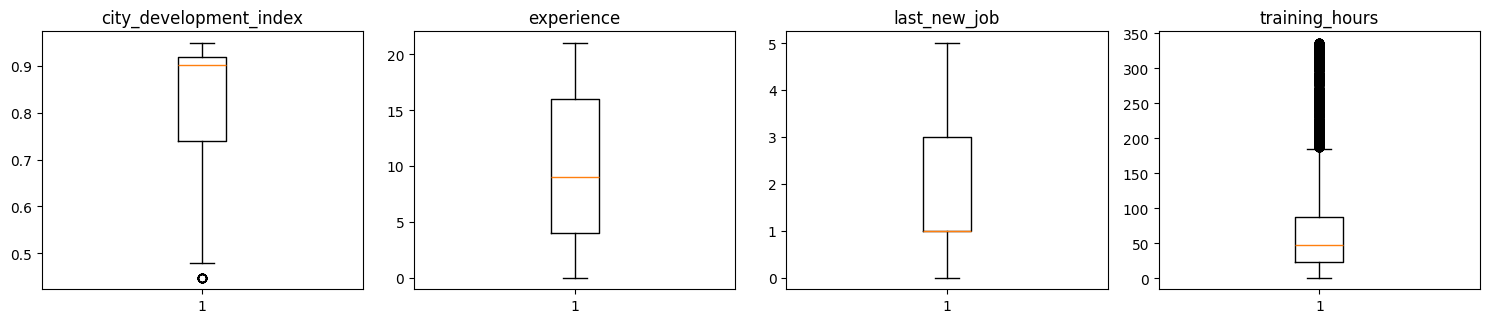

In [33]:
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data1[variable].dropna(), whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- The `experience` column is normally distributed, and there are no outliers.
- `last_new_job` has no outliers.
- `city_development_index` is skewed, but there is 1 outlier, with value less than 0.45. We need to check this further.
- There are lots of outliers in `training_hours`, these could be genuine values so we will not be removing them.


In [34]:
data1[data1["city_development_index"] < 0.45]

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1523,city_33,0.448,Has relevent experience,Part time course,Graduate,STEM,10.000,50-99,NGO,5.000,48,1
4744,city_33,0.448,No relevent experience,Full time course,Graduate,STEM,2.000,NaN,NaN,0.000,43,1
5010,city_33,0.448,No relevent experience,no_enrollment,Graduate,STEM,1.000,NaN,NaN,0.000,73,1
5265,city_33,0.448,No relevent experience,NaN,High School,NaN,5.000,NaN,Pvt Ltd,0.000,86,1
5567,city_33,0.448,Has relevent experience,Part time course,Masters,STEM,6.000,NaN,NaN,1.000,18,1
6127,city_33,0.448,No relevent experience,Full time course,Graduate,STEM,4.000,NaN,Public Sector,4.000,32,1
7724,city_33,0.448,Has relevent experience,no_enrollment,Graduate,STEM,7.000,50-99,Pvt Ltd,1.000,28,0
7864,city_33,0.448,Has relevent experience,no_enrollment,Graduate,STEM,8.000,NaN,NaN,5.000,74,0
9134,city_33,0.448,No relevent experience,Part time course,Masters,Other,2.000,<10,NGO,1.000,23,1
10401,city_33,0.448,No relevent experience,no_enrollment,Graduate,STEM,5.000,10000+,Pvt Ltd,2.000,36,0


* All such records with a city development index less than 0.45 are from city_33, hence they seem to represent true pattern and we don't need to treat them as outliers.

### Handling the `city` column

In [35]:
df["city"].nunique()

123

- The `city` column has 123 unique values
- For ~19K rows, having 123 unique values means this column isn't an identifier column
- It likely has predictive power for the target variable
- Let's check by checking the `city` against `target`

In [36]:
# Group by city and calculate the average 'target'
city_influence = data1.groupby('city')['target'].mean().sort_values(ascending=False)

print(city_influence.head(10)) # Cities with the highest job-seekers
print(city_influence.tail(10)) # Cities with the most loyal employees

city
city_171   1.000
city_139   0.800
city_155   0.786
city_42    0.692
city_107   0.667
city_33    0.647
city_179   0.600
city_11    0.595
city_21    0.591
city_145   0.587
Name: target, dtype: float64
city
city_97    0.077
city_77    0.031
city_140   0.000
city_129   0.000
city_111   0.000
city_2     0.000
city_39    0.000
city_62    0.000
city_82    0.000
city_8     0.000
Name: target, dtype: float64


- Locations such as city_171 and city_139 have a disproportionately high target mean, indicating most candidates are actively looking to move.
- city_140, city_62, and city_8 show zero intent for job changes based on the  data.
- Since `city` provides a strong predictive signal but has high cardinality (123 unique values), Target Encoding will be used to transform this into a numerical feature.
- We can't one-hot encode the `city` column, as it would create 123 new columns, creating a very sparse dataset.

### Data Preparation for modeling

In [37]:
X = data1.drop(["target"], axis=1)
y = data1["target"]

In [38]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(11494, 11) (3832, 11) (3832, 11)


In [39]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 11494
Number of rows in validation data = 3832
Number of rows in test data = 3832


### Handling Missing Values

In [40]:
# Checking for missing values in train, validation or test sets
print("Training set")
print("_"*30)
print(X_train.isna().sum())
print("\n")
print("Validation set")
print("_"*30)
print(X_val.isna().sum())
print("\n")
print("Test set")
print("_"*30)
print(X_test.isna().sum())
print("\n")

Training set
______________________________
city                         0
city_development_index       0
relevent_experience          0
enrolled_university        217
education_level            272
major_discipline          1677
experience                  42
company_size              3566
company_type              3682
last_new_job               248
training_hours               0
dtype: int64


Validation set
______________________________
city                         0
city_development_index       0
relevent_experience          0
enrolled_university         85
education_level             99
major_discipline           567
experience                  13
company_size              1178
company_type              1223
last_new_job                84
training_hours               0
dtype: int64


Test set
______________________________
city                         0
city_development_index       0
relevent_experience          0
enrolled_university         84
education_level             89
maj

In [41]:
from sklearn.impute import SimpleImputer

# Get list of categorical and numerical columns
cat_cols = list(X_train.select_dtypes(include='object').columns)
num_cols = list(X_train.select_dtypes(include=['int', 'float']).columns)

In [42]:
print("Categorical Columns: ")
print(cat_cols)
print("Numerical Columns: ")
print(num_cols)

Categorical Columns: 
['city', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']
Numerical Columns: 
['city_development_index', 'experience', 'last_new_job', 'training_hours']


In [43]:
# Impute categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Impute numerical columns
num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [44]:
# Checking that no column has missing values in train, validation or test sets
print("Training set")
print("_"*30)
print(X_train.isna().sum())
print("\n")
print("Validation set")
print("_"*30)
print(X_val.isna().sum())
print("\n")
print("Test set")
print("_"*30)
print(X_test.isna().sum())
print("\n")

Training set
______________________________
city                      0
city_development_index    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64


Validation set
______________________________
city                      0
city_development_index    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
dtype: int64


Test set
______________________________
city                      0
city_development_index    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0


* All missing values have been treated.

### Encoding the `city` column

EDA shows that an employee's city holds strong predictive power regarding their risk of leaving. However, city is a categorical variable with **high cardinality** (123 unique values). Traditional One-Hot Encoding is impractical because creating 123 new binary columns would cause severe data sparsity and inflate dimensions, which hurts model performance and efficiency.

To retain this predictive signal without adding unnecessary columns, we used **Target Encoding**.

It converts the categorical text into a single numerical feature by replacing each city's name with the historical average churn rate of that specific city (e.g., if 45% of employees from "city_171" leave, the name is replaced with 0.45). It captures the exact risk profile of each city directly inside a single feature, aligning perfectly with our EDA finding that specific cities carry vastly different flight risks.

In [45]:
X_train['city'].head()

,city
15429,city_21
15485,city_128
15065,city_103
15962,city_16
12470,city_16


In [46]:
X_test['city'].head()

,city
7152,city_21
16124,city_21
6536,city_114
306,city_103
4995,city_21


In [47]:
X_val['city'].head()

,city
3046,city_103
10462,city_16
9108,city_114
2328,city_76
16197,city_16


In [48]:
from sklearn.preprocessing import TargetEncoder

te = TargetEncoder(smooth="auto", random_state=42)

# Fit and Transform the Training Set
X_train['city'] = te.fit_transform(X_train[['city']], y_train)

# Transform the Validation and Test Sets
X_val['city'] = te.transform(X_val[['city']])
X_test['city'] = te.transform(X_test[['city']])

In [49]:
X_train['city'].head()

,city
15429,0.597
15485,0.476
15065,0.219
15962,0.118
12470,0.116


In [50]:
X_train.head()

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
15429,0.597,0.624,No relevent experience,no_enrollment,High School,STEM,2.000,50-99,Pvt Ltd,0.000,43.000
15485,0.476,0.527,No relevent experience,Full time course,High School,STEM,4.000,50-99,Pvt Ltd,0.000,178.000
15065,0.219,0.920,Has relevent experience,no_enrollment,Graduate,STEM,3.000,10000+,Other,1.000,134.000
15962,0.118,0.910,Has relevent experience,no_enrollment,Masters,STEM,5.000,10000+,Pvt Ltd,1.000,92.000
12470,0.116,0.910,No relevent experience,Part time course,Graduate,STEM,12.000,50-99,Pvt Ltd,2.000,111.000


### Creating Dummy Variables

In [51]:
# Selecting categorical columns to perform one hot encoding on
# 'city' is now target-encoded and should be numerical, so it's excluded from cat_cols
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

['relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'company_size',
 'company_type']

In [52]:
print("Shape before encoding:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Shape before encoding:
Train: (11494, 11)
Val:   (3832, 11)
Test:  (3832, 11)


In [53]:
# import OneHotEnconder
from sklearn.preprocessing import OneHotEncoder

# Initialize the Encoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")

# Fit on Training set, transform all
train_encoded = ohe.fit_transform(X_train[cat_cols])
val_encoded = ohe.transform(X_val[cat_cols])
test_encoded = ohe.transform(X_test[cat_cols])

In [54]:
# Drop the original text columns and join the new binary (0/1) columns
X_train = X_train.drop(columns=cat_cols).join(train_encoded)
X_val = X_val.drop(columns=cat_cols).join(val_encoded)
X_test = X_test.drop(columns=cat_cols).join(test_encoded)

In [55]:
print("Shape after encoding:")
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Shape after encoding:
Train: (11494, 35)
Val:   (3832, 35)
Test:  (3832, 35)


* After encoding there are 35 columns.

In [56]:
X_train.columns.to_list()

['city',
 'city_development_index',
 'experience',
 'last_new_job',
 'training_hours',
 'relevent_experience_Has relevent experience',
 'relevent_experience_No relevent experience',
 'enrolled_university_Full time course',
 'enrolled_university_Part time course',
 'enrolled_university_no_enrollment',
 'education_level_Graduate',
 'education_level_High School',
 'education_level_Masters',
 'education_level_Phd',
 'education_level_Primary School',
 'major_discipline_Arts',
 'major_discipline_Business Degree',
 'major_discipline_Humanities',
 'major_discipline_No Major',
 'major_discipline_Other',
 'major_discipline_STEM',
 'company_size_100-500',
 'company_size_1000-4999',
 'company_size_10000+',
 'company_size_50-99',
 'company_size_500-999',
 'company_size_5000-9999',
 'company_size_<10',
 'company_size_Oct-49',
 'company_type_Early Stage Startup',
 'company_type_Funded Startup',
 'company_type_NGO',
 'company_type_Other',
 'company_type_Public Sector',
 'company_type_Pvt Ltd']

In [57]:
X_train.head()

,city,city_development_index,experience,last_new_job,training_hours,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_Graduate,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_size_100-500,company_size_1000-4999,company_size_10000+,company_size_50-99,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_Oct-49,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
15429,0.597,0.624,2.000,0.000,43.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
15485,0.476,0.527,4.000,0.000,178.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
15065,0.219,0.920,3.000,1.000,134.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
15962,0.118,0.910,5.000,1.000,92.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
12470,0.116,0.910,12.000,2.000,111.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


# Model Building

## Model evaluation criterion

**Model can make wrong predictions as:**
1. Predicting an employee is looking for a job change but in reality, the employee is not looking for a change - Loss of resources (spending retention budget on someone who wasn't leaving anyway)
2. Predicting an employee is not looking for a job change but the employee is looking for a job change  - Loss of employee (resulting in high replacement costs)

**Which case is more important?**
* Predicting an employee is not looking for a job change but the employee is looking for a job change i.e. losing on an employee as the employee will not be targeted by the HR team when they should be targeted.

**How to reduce this loss i.e need to reduce False Negatives?**
* Company would want Recall to be maximized, greater the Recall lesser the chances of false negatives.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [58]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [59]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

In [60]:
model_results = pd.DataFrame()

### Model Building - Original Data

In [61]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

In [62]:
print(f"{'Model':<20} | {'Train Recall':<15} | {'Val Recall':<15} | {'Recall Diff':<15}")
print("-" * 75)

original_results = []
for name, model in models:
    model.fit(X_train, y_train)

    # Calculate metrics
    train_score = recall_score(y_train, model.predict(X_train))
    val_score = recall_score(y_val, model.predict(X_val))
    diff = train_score - val_score

    original_results.append({
        "Strategy": "Original",
        "Model": name,
        "Train Recall": train_score,
        "Val Recall": val_score,
        "Recall Diff": diff
    })

    # Print results side-by-side with left alignment
    print(f"{name:<20} | {train_score:<15.4f} | {val_score:<15.4f} | {diff:<15.4f}")

model_results = pd.concat([model_results, pd.DataFrame(original_results)], ignore_index=True)

Model                | Train Recall    | Val Recall      | Recall Diff    
---------------------------------------------------------------------------
Bagging              | 0.9271          | 0.3389          | 0.5882         
Random forest        | 0.9997          | 0.3902          | 0.6095         
GBM                  | 0.4616          | 0.4362          | 0.0254         
Adaboost             | 0.2882          | 0.2741          | 0.0141         
dtree                | 1.0000          | 0.3828          | 0.6172         


- For selecting the best models, we need to maximise training score and validation score, as well as minimise variance (training - validation scores)
- According to the above criteria, GBM has the best performance followed by Random Forest

### Model Building - Oversampled Data

In [63]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 2866
Before Oversampling, counts of label 'No': 8628 

After Oversampling, counts of label 'Yes': 8628
After Oversampling, counts of label 'No': 8628 

After Oversampling, the shape of train_X: (17256, 35)
After Oversampling, the shape of train_y: (17256,) 



In [64]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

In [65]:
print(f"{'Model':<20} | {'Train Recall':<15} | {'Val Recall':<15} | {'Recall Diff':<15}")
print("-" * 75)

oversampled_results = []
for name, model in models:
    model.fit(X_train_over, y_train_over)

    # Calculate metrics
    train_score = recall_score(y_train_over, model.predict(X_train_over))
    val_score = recall_score(y_val, model.predict(X_val))
    diff = train_score - val_score

    oversampled_results.append({
        "Strategy": "Oversampled",
        "Model": name,
        "Train Recall": train_score,
        "Val Recall": val_score,
        "Recall Diff": diff
    })

    # Print results side-by-side with left alignment
    print(f"{name:<20} | {train_score:<15.4f} | {val_score:<15.4f} | {diff:<15.4f}")

model_results = pd.concat([model_results, pd.DataFrame(oversampled_results)], ignore_index=True)

Model                | Train Recall    | Val Recall      | Recall Diff    
---------------------------------------------------------------------------
Bagging              | 0.9760          | 0.4728          | 0.5032         
Random forest        | 0.9998          | 0.4927          | 0.5071         
GBM                  | 0.8417          | 0.5408          | 0.3009         
Adaboost             | 0.8024          | 0.5356          | 0.2668         
dtree                | 0.9995          | 0.5335          | 0.4661         


- For selecting the best models, we need to maximise training score and validation score, as well as minimise variance (training - validation scores)
- According to the above criteria, GBM has the best performance followed by Adaboost

### Model Building - Undersampled Data

In [66]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [67]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 2866
Before Under Sampling, counts of label 'No': 8628 

After Under Sampling, counts of label 'Yes': 2866
After Under Sampling, counts of label 'No': 2866 

After Under Sampling, the shape of train_X: (5732, 35)
After Under Sampling, the shape of train_y: (5732,) 



In [68]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

In [69]:
print(f"{'Model':<20} | {'Train Recall':<15} | {'Val Recall':<15} | {'Recall Diff':<15}")
print("-" * 75)

undersampled_results = []
for name, model in models:
    model.fit(X_train_un, y_train_un)

    # Calculate metrics
    train_score = recall_score(y_train_un, model.predict(X_train_un))
    val_score = recall_score(y_val, model.predict(X_val))
    diff = train_score - val_score

    undersampled_results.append({
        "Strategy": "Undersampled",
        "Model": name,
        "Train Recall": train_score,
        "Val Recall": val_score,
        "Recall Diff": diff
    })

    # Print results side-by-side with left alignment
    print(f"{name:<20} | {train_score:<15.4f} | {val_score:<15.4f} | {diff:<15.4f}")

model_results = pd.concat([model_results, pd.DataFrame(undersampled_results)], ignore_index=True)

Model                | Train Recall    | Val Recall      | Recall Diff    
---------------------------------------------------------------------------
Bagging              | 0.9721          | 0.6485          | 0.3236         
Random forest        | 0.9997          | 0.7134          | 0.2863         
GBM                  | 0.7781          | 0.7364          | 0.0417         
Adaboost             | 0.7495          | 0.7019          | 0.0476         
dtree                | 0.9997          | 0.6538          | 0.3459         


- For selecting the best models, we need to maximise training score and validation score, as well as minimise variance (training - validation scores)
- According to the above criteria, GBM has the best performance followed by Adaboost

In [70]:
model_results

,Strategy,Model,Train Recall,Val Recall,Recall Diff
0,Original,Bagging,0.927,0.339,0.588
1,Original,Random forest,1.000,0.390,0.609
2,Original,GBM,0.462,0.436,0.025
3,Original,Adaboost,0.288,0.274,0.014
4,Original,dtree,1.000,0.383,0.617
5,Oversampled,Bagging,0.976,0.473,0.503
6,Oversampled,Random forest,1.000,0.493,0.507
7,Oversampled,GBM,0.842,0.541,0.301
8,Oversampled,Adaboost,0.802,0.536,0.267
9,Oversampled,dtree,1.000,0.533,0.466


- Undersampled GBM & AdaBoost: These are our strongest candidates, already achieving the highest Validation Recall (\~0.73) with very low Recall Differences (\~0.04). We will tune them to further improve their performance.

- Original GBM: The Original strategy struggled with the 25/75 class imbalance, but Gradient Boosting has internal mechanisms to handle minority classes. We are tuning this to see if a sophisticated model can handle the natural data distribution without the need for manual resampling.

- Oversampled Random Forest & Adaboost: In the baseline, these models showed a massive gap (up to 0.51) between Train and Validation Recall. They are currently "memorizing" the synthetic points created during oversampling. We will tune them to see if can force these models to learn general patterns instead of noise.


## Hyperparameter Tuning

### Tuning AdaBoostClassifier model with Undersampled data

In [71]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

CPU times: user 1.44 s, sys: 182 ms, total: 1.62 s
Wall time: 32.6 s


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.05,
                                                          1],
                                        'n_estimators': array([10, 20, 30])},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [72]:
print("Best parameters are {} \n CV score = {}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} 
 CV score = 0.8360076861800779:


In [73]:
abc1_tuned = randomized_cv.best_estimator_

In [74]:
# Checking model's performance on training set
abc1_train = model_performance_classification_sklearn(abc1_tuned, X_train_un, y_train_un)
abc1_train

,Accuracy,Recall,Precision,F1
0,0.680,0.837,0.637,0.723


In [75]:
# Checking model's performance on validation set
abc1_val = model_performance_classification_sklearn(abc1_tuned, X_val, y_val)
abc1_val

,Accuracy,Recall,Precision,F1
0,0.604,0.816,0.368,0.507


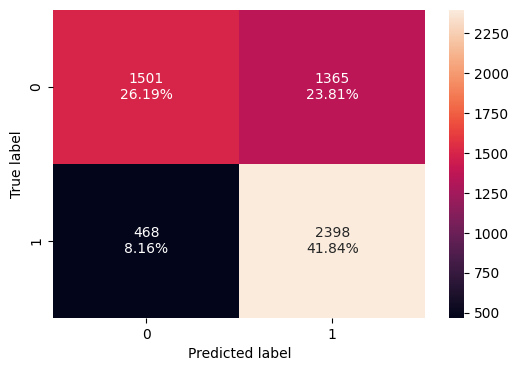

In [76]:
confusion_matrix_sklearn(abc1_tuned, X_train_un, y_train_un)

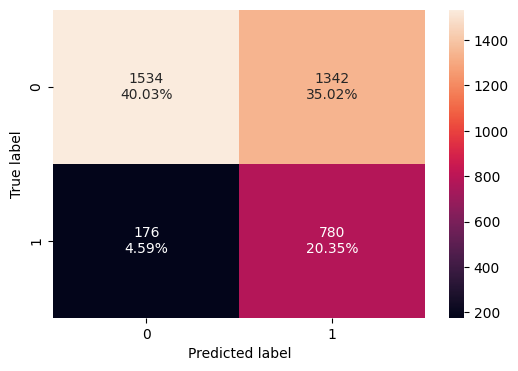

In [77]:
confusion_matrix_sklearn(abc1_tuned, X_val, y_val)

### Tuning  Gradient Boosting model with Undersampled Data

In [78]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

CPU times: user 2.45 s, sys: 218 ms, total: 2.67 s
Wall time: 1min 54s


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.05, 1],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([125, 150]),
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [79]:
print("Best parameters are {} \n CV score = {}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(150), 'max_features': 0.7, 'learning_rate': 0.05} 
 CV score = 0.7585396257851882:


In [80]:
gbm1_tuned = randomized_cv.best_estimator_

In [81]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    gbm1_tuned, X_train_un, y_train_un
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.757,0.776,0.748,0.762


In [82]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(gbm1_tuned, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.731,0.732,0.475,0.576


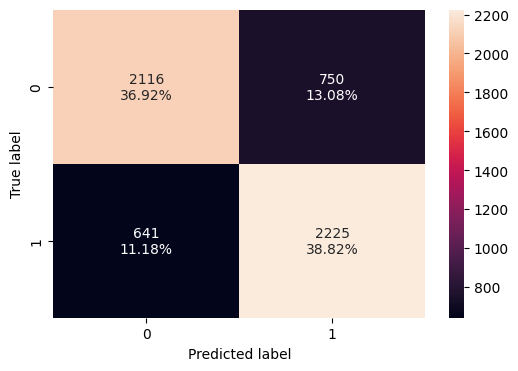

In [83]:
confusion_matrix_sklearn(gbm1_tuned, X_train_un, y_train_un)

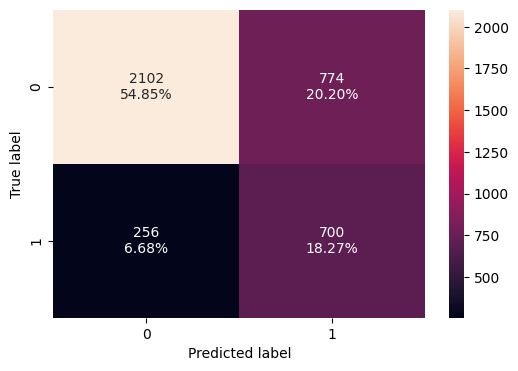

In [84]:
confusion_matrix_sklearn(gbm1_tuned, X_val, y_val)

### Tuning  Gradient Boosting model with Original Data

In [85]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

CPU times: user 2.74 s, sys: 302 ms, total: 3.04 s
Wall time: 3min 23s


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.05, 1],
                                        'max_features': [0.5, 0.7, 1],
                                        'n_estimators': array([125, 150]),
                                        'subsample': [0.8, 0.9, 1]},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [86]:
print("Best parameters are {} \n CV score = {}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 0.05} 
 CV score = 0.4358039780846575:


In [87]:
gbm2_tuned = randomized_cv.best_estimator_

In [88]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(
    gbm2_tuned, X_train, y_train
)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.793,0.455,0.614,0.522


In [89]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(gbm2_tuned, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.780,0.432,0.580,0.495


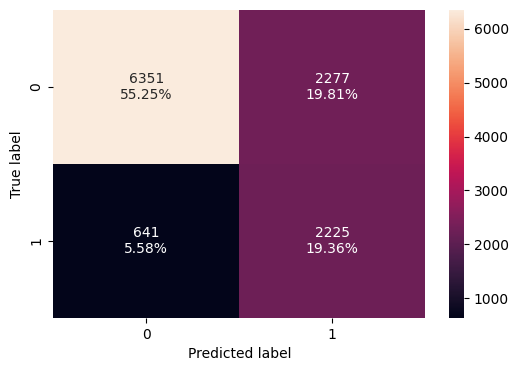

In [90]:
confusion_matrix_sklearn(gbm1_tuned, X_train, y_train)

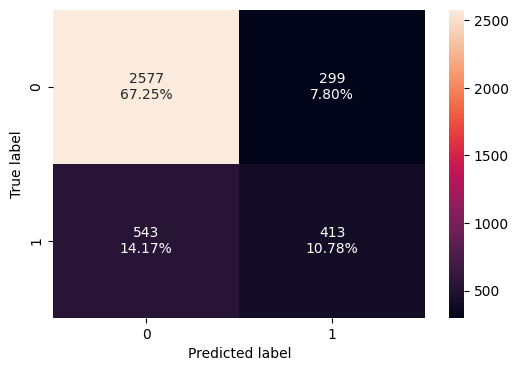

In [91]:
confusion_matrix_sklearn(gbm2_tuned, X_val, y_val)

### Tuning AdaBoostClassifier model with Oversampled data

In [92]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

CPU times: user 2.17 s, sys: 390 ms, total: 2.56 s
Wall time: 1min 42s


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.05,
                                                          1],
                                        'n_estimators': array([10, 20, 30])},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [93]:
print("Best parameters are {} \n CV score = {}:" .format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(10), 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} 
 CV score = 0.9282566712009002:


In [94]:
abc2_tuned = randomized_cv.best_estimator_

In [95]:
# Checking model's performance on training set
abc2_train = model_performance_classification_sklearn(abc2_tuned, X_train_over, y_train_over)
abc2_train

,Accuracy,Recall,Precision,F1
0,0.702,0.928,0.639,0.757


In [96]:
# Checking model's performance on validation set
abc2_val = model_performance_classification_sklearn(abc2_tuned, X_val, y_val)
abc2_val

,Accuracy,Recall,Precision,F1
0,0.572,0.853,0.352,0.498


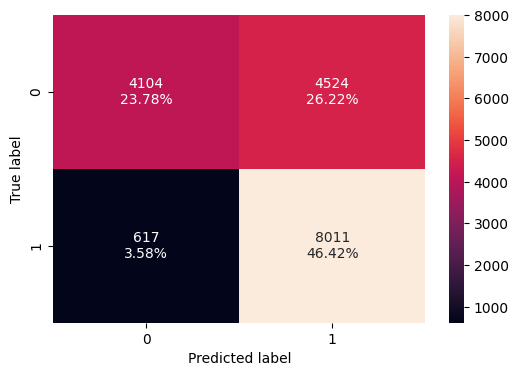

In [97]:
confusion_matrix_sklearn(abc2_tuned, X_train_over, y_train_over)

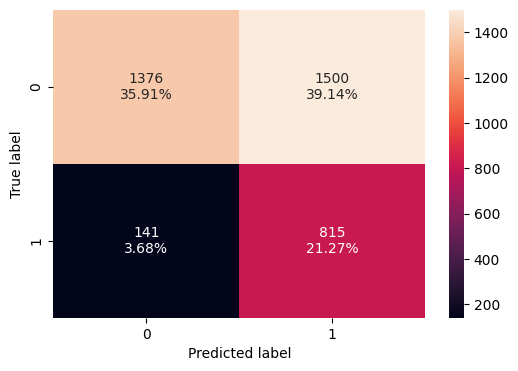

In [98]:
confusion_matrix_sklearn(abc2_tuned, X_val, y_val)

### Tuning Random Forest model with Oversampled data

In [99]:
%%time

#defining model
Model = RandomForestClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(100, 250, 50),
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [0.5, 0.7, 'sqrt', 'log2'],
    "min_samples_split": [2, 5, 10],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

CPU times: user 7.13 s, sys: 1.09 s, total: 8.22 s
Wall time: 12min 7s


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15],
                                        'max_features': [0.5, 0.7, 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 5, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([100, 150, 200])},
                   random_state=1,
                   scoring=make_scorer(recall_score, response_method='predict'))

In [100]:
print("Best parameters are {} \n CV score = {}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(100), 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 5} 
 CV score = 0.8363446017431609:


In [101]:
rf1_tuned = randomized_cv.best_estimator_

In [102]:
# Checking model's performance on training set
rf1_train = model_performance_classification_sklearn(rf1_tuned, X_train_over, y_train_over)
rf1_train

,Accuracy,Recall,Precision,F1
0,0.809,0.854,0.784,0.817


In [103]:
# Checking model's performance on validation set
rf1_val = model_performance_classification_sklearn(rf1_tuned, X_val, y_val)
rf1_val

,Accuracy,Recall,Precision,F1
0,0.742,0.674,0.488,0.566


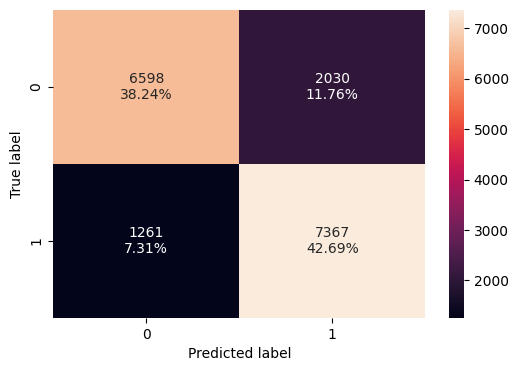

In [104]:
confusion_matrix_sklearn(rf1_tuned, X_train_over, y_train_over)

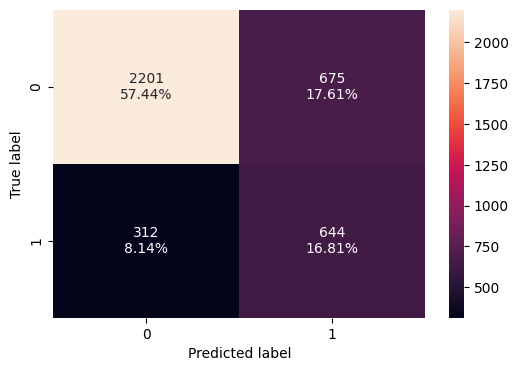

In [105]:
confusion_matrix_sklearn(rf1_tuned, X_val, y_val)

## Model Comparison and Final Model Selection

In [106]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        abc1_train.T,
        gbm1_train.T,
        gbm2_train.T,
        abc2_train.T,
        rf1_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Adaboost trained with Undersampled data",
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "Adaboost trained with Oversampled data",
    "Random Forest trained with Oversampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Adaboost trained with Undersampled data,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,Adaboost trained with Oversampled data,Random Forest trained with Oversampled data
Accuracy,0.680,0.757,0.793,0.702,0.809
Recall,0.837,0.776,0.455,0.928,0.854
Precision,0.637,0.748,0.614,0.639,0.784
F1,0.723,0.762,0.522,0.757,0.817


In [107]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [abc1_val.T,
     gbm1_val.T,
     gbm2_val.T,
     abc2_val.T,
     rf1_val.T],
    axis=1,
)
models_val_comp_df.columns = [
    "Adaboost trained with Undersampled data",
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "Adaboost trained with Oversampled data",
    "Random Forest trained with Oversampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Adaboost trained with Undersampled data,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,Adaboost trained with Oversampled data,Random Forest trained with Oversampled data
Accuracy,0.604,0.731,0.780,0.572,0.742
Recall,0.816,0.732,0.432,0.853,0.674
Precision,0.368,0.475,0.580,0.352,0.488
F1,0.507,0.576,0.495,0.498,0.566


- AdaBoost (Undersampled): This is one of the strongest choices if the primary focus remains strictly on minimizing overfitting. It achieves a high Validation Recall (0.81) with excellent stability and almost no overfitting (Train Recall is 0.83).

- Gradient Boosting (Undersampled): This is the best choice for a more balanced model. While its Validation Recall (0.73) is lower than AdaBoost (Undersampled), it retains much higher Validation Accuracy (0.73) and Precision (0.47), while showing a small gap (0.05) between Train and Validation recall performance.

- AdaBoost (Oversampled): This model has the highest Validation Recall (0.85) among the viable models, although it shows a larger gap from its Train Recall (0.92) and suffers from a low Validation Precision (0.35) and Accuracy (0.57).

- Gradient Boosting (Original): This model should be discarded. It has very poor Validation Recall (0.43). This remains the weakest candidate for this metric (recall).

- Random Forest (Oversampled):  This model is not a great performer with a Validation recall of (0.67). It also shows a significant drop-off from its Train Recall (0.85), indicating tuning did not fully resolve its overfitting.

- We will go ahead with Adaboost trained on Oversampled data as the final model, as it has the highest recall. It also has good precision among the top models, so it has less false positives. Let's check its performance on the test set.

In [108]:
# Let's check the performance on test set
abc2_test = model_performance_classification_sklearn(abc2_tuned, X_test, y_test)
abc2_test

,Accuracy,Recall,Precision,F1
0,0.567,0.852,0.349,0.495


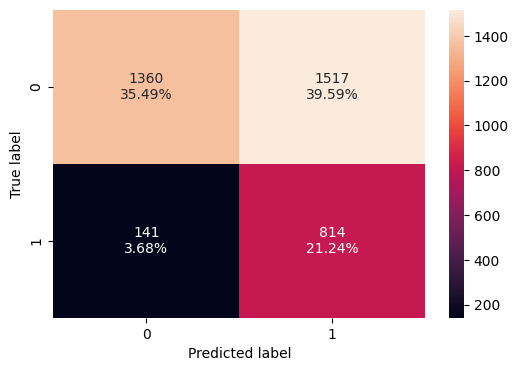

In [109]:
confusion_matrix_sklearn(abc2_tuned, X_test, y_test)

- The Adaboost model trained on oversampled data has given ~85% recall on the test set
- This performance is in line with what we achieved with this model on the train and validation sets
- So, this is a well generalized model

### Feature Importance

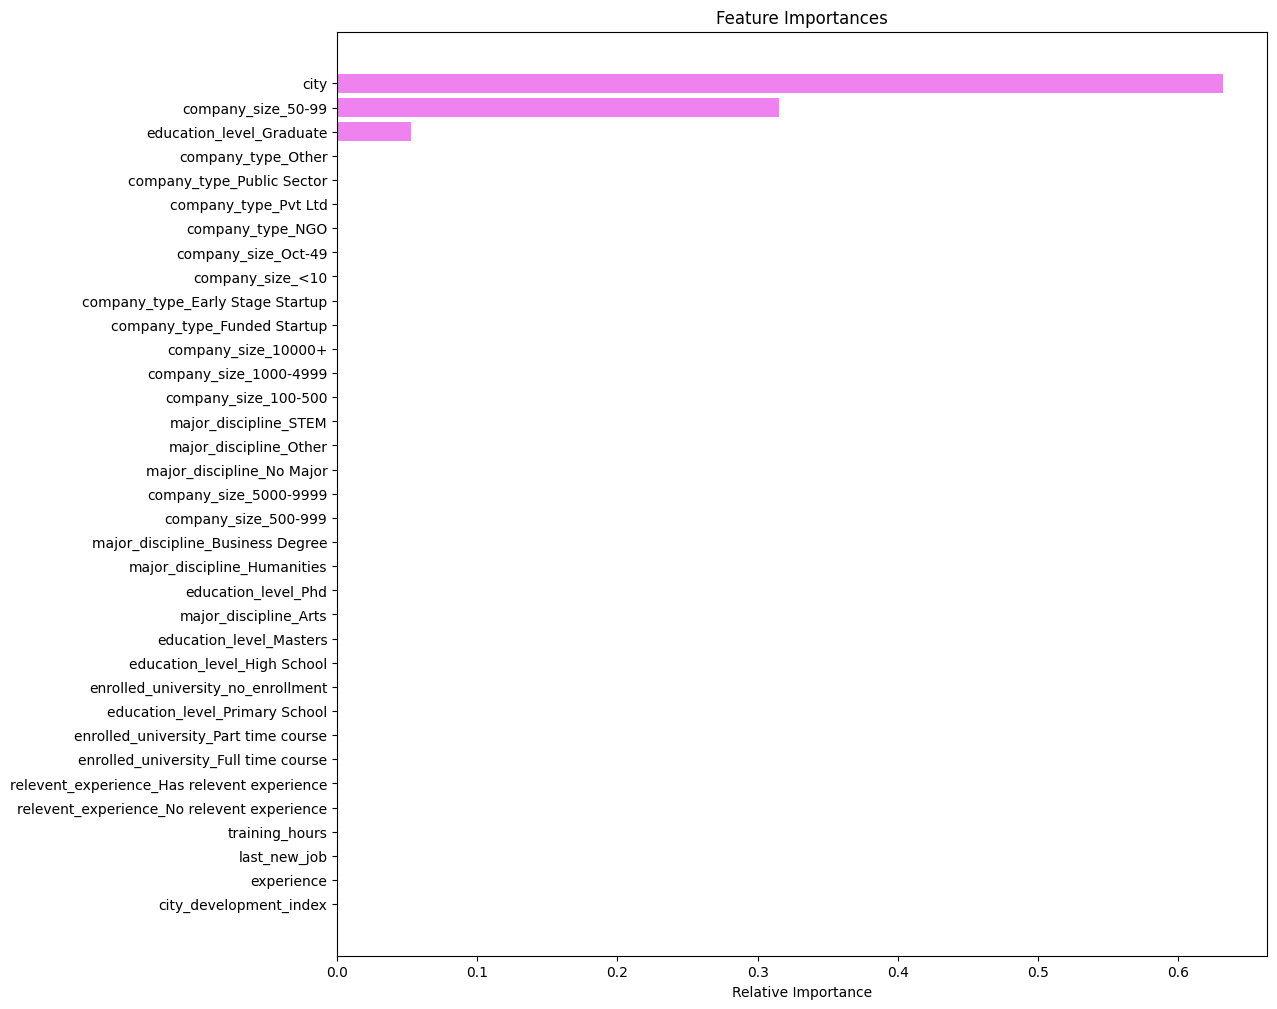

In [110]:
feature_names = X_train.columns
importances = abc2_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- We can see that `city`, `company_size_50-99` and `education_level_Graduate` are the most important features for making predictions

# Business Insights and Recommendations

- The city an employee originates from acts as a strong predictor of attrition, as shown by the feature importances of the final model. This is further supported by the `city_development_index` variable, which has a negative relationship with the target variable; employees from lower-development index cities are much more likely to leave compared to those from highly developed areas. They are likely using the company's training to upskill and seek out better roles in metropolitan hubs.

- Establish Internal Mobility Programs for Low-CDI Employees:
Since employees from lower-tier cities are leaving to find better opportunities in metropolitan hubs, Sterling Global Operations could proactively offer internal transfer opportunities. Upon successful completion of the training program, high-performing specialists from these regions could be offered relocations or remote roles attached to tier-1 city projects.

- Employees with less than 10 years of experience are highly prone to leaving, as seen in EDA.
Freshers (with <1 year of experience) and candidates with no relevant experience have a high churn rate, indicating they use the training as a primary stepping stone to enter the industry elsewhere.
- Because freshers (<1 year) and those without relevant experience are using the training to make themselves marketable, the firm could protect its ROI by restructuring how training is deployed:

    1. Require a "Training Bond" or clawback agreement for high-cost, advanced training, stipulating that the employee must remain with the company for a set period (e.g., 1–2 years) or reimburse the training costs.

    2. Limit advanced, high-stakes training to employees who have crossed a specific tenure threshold (e.g., 2+ years) or possess relevant background experience.

# <a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

### Univariate analysis

In [111]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Observations on city_development_index

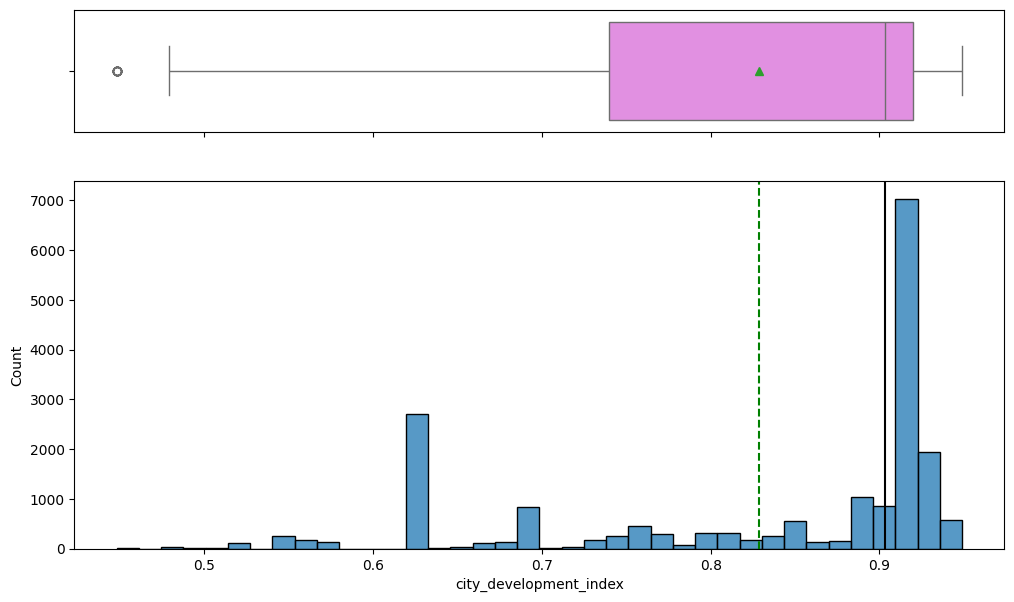

In [112]:
histogram_boxplot(data, "city_development_index")

* Distribution of city_development_index is left-skewed.
* Cities with city_development_index less than ~0.45 are outliers - such cities might be underdeveloped or tier 3 cities.
* Let's explore it further.

In [113]:
data[data["city_development_index"] < 0.45]

,city,city_development_index,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1523,city_33,0.448,Has relevent experience,Part time course,Graduate,STEM,10,50-99,NGO,>4,48,1
4744,city_33,0.448,No relevent experience,Full time course,Graduate,STEM,2,NaN,NaN,never,43,1
5010,city_33,0.448,No relevent experience,no_enrollment,Graduate,STEM,1,NaN,NaN,never,73,1
5265,city_33,0.448,No relevent experience,NaN,High School,NaN,5,NaN,Pvt Ltd,never,86,1
5567,city_33,0.448,Has relevent experience,Part time course,Masters,STEM,6,NaN,NaN,1,18,1
6127,city_33,0.448,No relevent experience,Full time course,Graduate,STEM,4,NaN,Public Sector,4,32,1
7724,city_33,0.448,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,28,0
7864,city_33,0.448,Has relevent experience,no_enrollment,Graduate,STEM,8,NaN,NaN,>4,74,0
9134,city_33,0.448,No relevent experience,Part time course,Masters,Other,2,<10,NGO,1,23,1
10401,city_33,0.448,No relevent experience,no_enrollment,Graduate,STEM,5,10000+,Pvt Ltd,2,36,0


* All such records with a city development index less than 0.45 are from city_33, hence they seem to represent true pattern and we don't need to treat them as outliers.

### Observations on training_hours

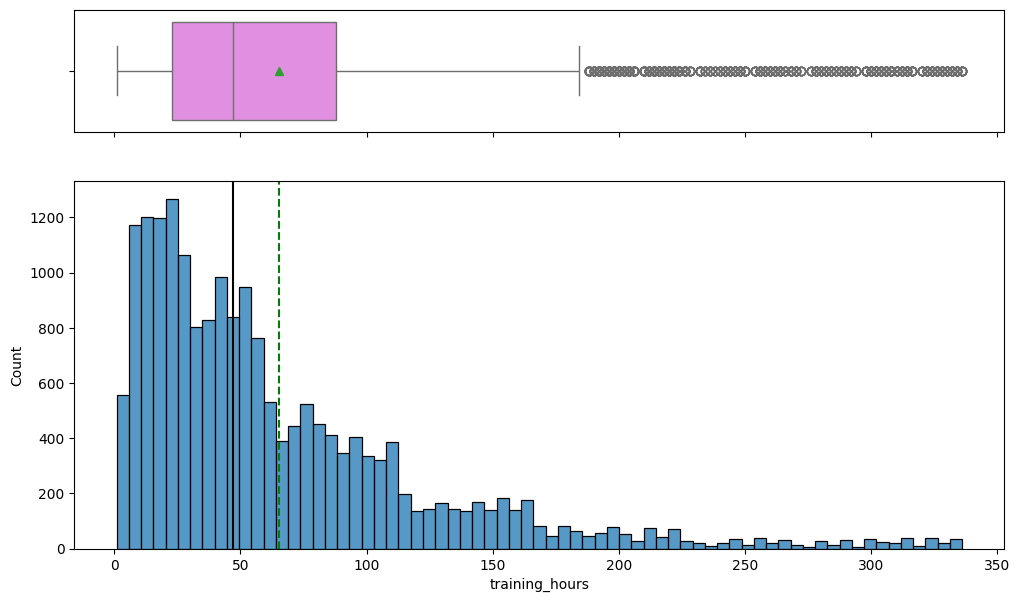

In [114]:
histogram_boxplot(data, "training_hours")

* Distribution of training_hours is right-skewed with many outliers.
* From the boxplot, we can see that employees with more than ~175hrs of training are outliers.

In [115]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Observations on Target

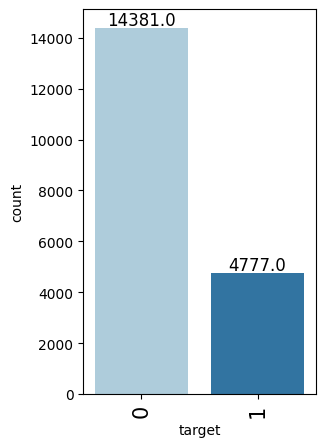

In [116]:
labeled_barplot(data, "target")

* There is a class imbalance in the dataset.

### Observations on relevant_experience

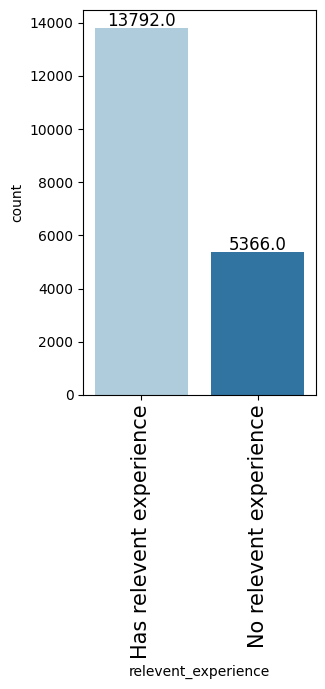

In [117]:
labeled_barplot(data, "relevent_experience")

* 72% of the employees have some relevant experience.

### Observations on enrolled_university

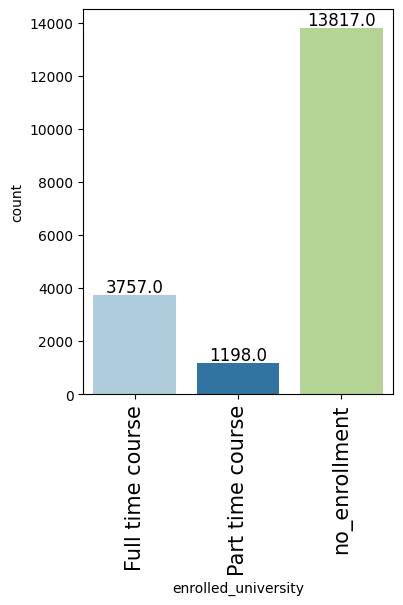

In [118]:
labeled_barplot(data, "enrolled_university")

* 72.1% of the employees had no enrollment in universities followed by 19.6% of the employees with the full-time course.

### Observations on education_level

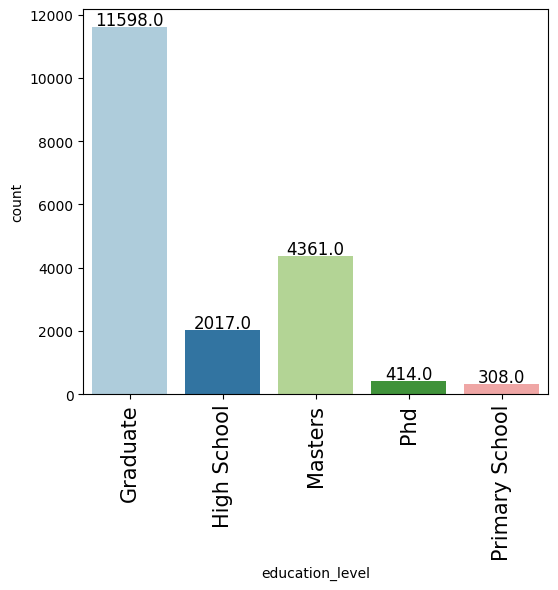

In [119]:
labeled_barplot(data, "education_level")

* 60.5% of the employees are graduates, followed by 22.8% of the employees having Masters degree.

### Observations on major_discipline

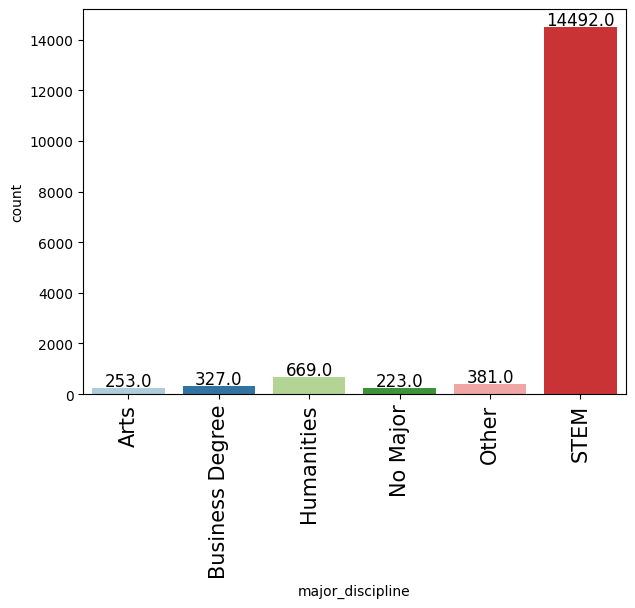

In [120]:
labeled_barplot(data, "major_discipline")

* 75.5% of the employees have STEM as their major discipline. STEM includes programs in science, technology, engineering, and mathematics.

### Observations on company_size

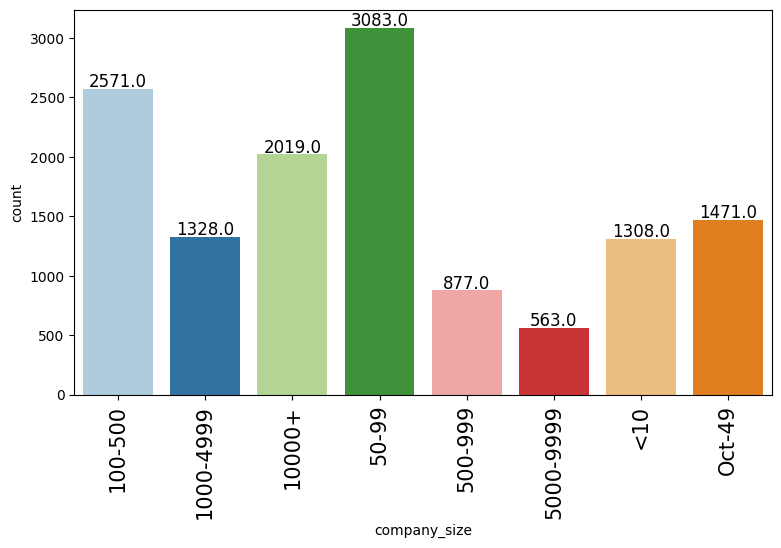

In [121]:
labeled_barplot(data, "company_size")

* 16.1% of the employees have worked in a company with 50-99 employees, followed by 13.4% of the employees who have worked in a company with 100-500.

### Observations on company_type

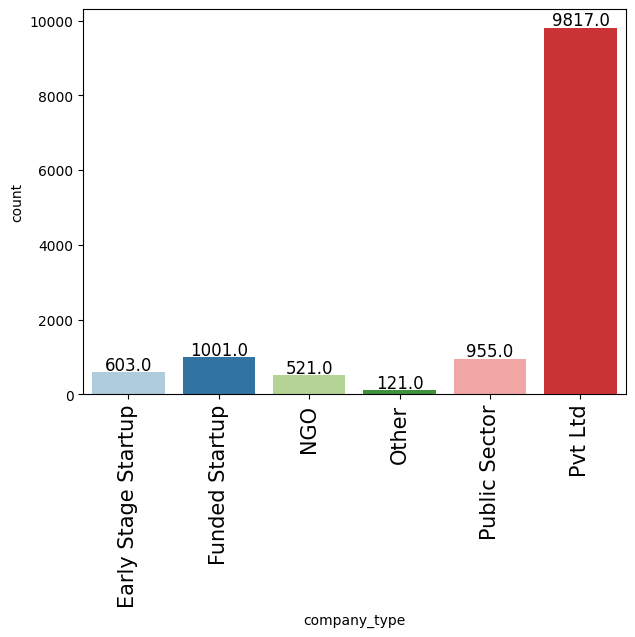

In [122]:
labeled_barplot(data, "company_type")

* 51.2% of the employees have worked in private companies, followed by 8.3% employees in startups.

### Observations on last_new_job

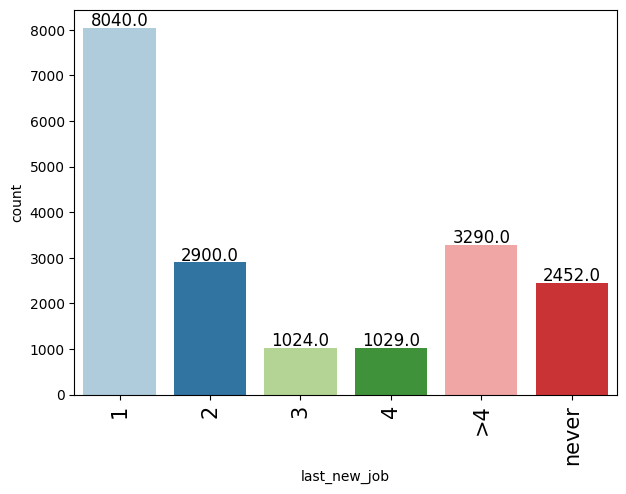

In [123]:
labeled_barplot(data, "last_new_job")

* 42% of the employees have a difference of 1 year between their current and previous job followed by 17.2% of the employees with more than 4 years of difference.
* Never here can mean that employees has never worked before(freshers) or is not working right now.

### Bivariate Analysis

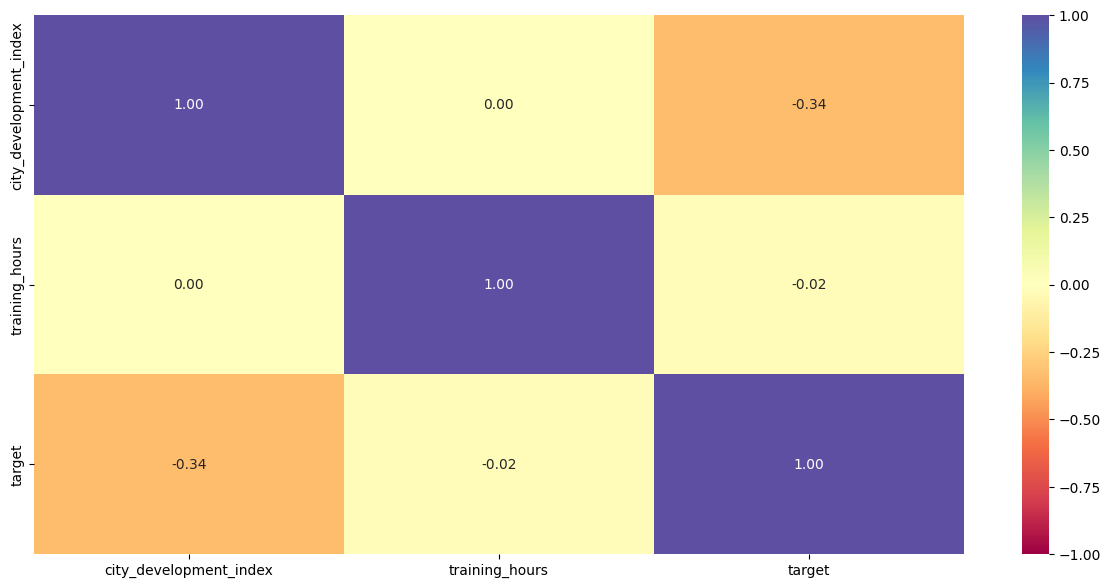

In [124]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is no strong correlation either with the target or between any independent variable.
* City development index has a negative relation with the target.

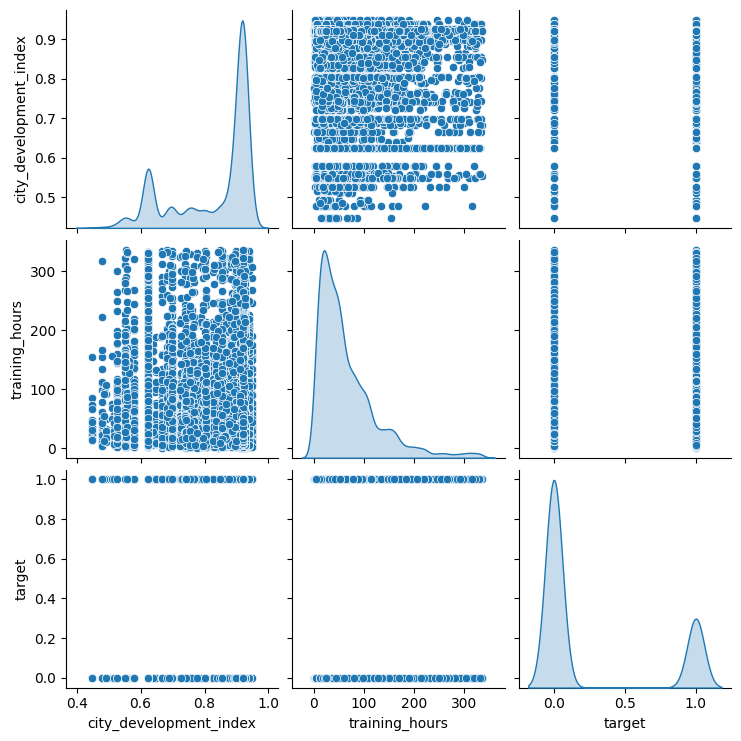

In [125]:
sns.pairplot(data=data, diag_kind="kde")
plt.show()

* Encoding 1 and 0 to 'yes' and 'no' respectively, for analysis.

In [126]:
data["target"].replace(1, "yes", inplace=True)
data["target"].replace(0, "no", inplace=True)

In [127]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### target vs city

target       no   yes    All
city                        
All       14381  4777  19158
city_21    1105  1597   2702
city_103   3427   928   4355
city_160    646   199    845
city_16    1354   179   1533
...         ...   ...    ...
city_2        7     0      7
city_39      11     0     11
city_62       5     0      5
city_8        4     0      4
city_82       4     0      4

[124 rows x 3 columns]
------------------------------------------------------------------------------------------------------------------------


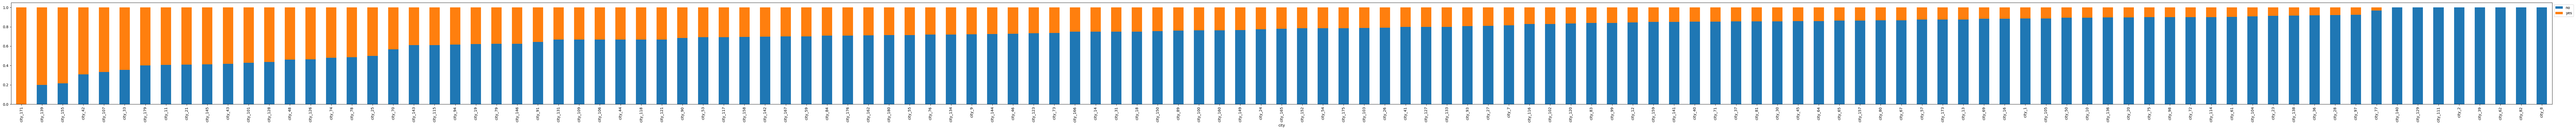

In [128]:
stacked_barplot(data, "city", "target")

* Cities 171,139, 155, and 42 show the highest percentage of employees looking for a job.
* Cities with the highest percentage of employees looking for a job might be from tier 2 or tier 3 cities looking for better opportunities.
* This column captures a clear difference between employees looking for a job and those who are not, it can act as an important predictor.

### target vs relevant_experience

target                      no   yes    All
relevent_experience                        
All                      14381  4777  19158
Has relevent experience  10831  2961  13792
No relevent experience    3550  1816   5366
------------------------------------------------------------------------------------------------------------------------


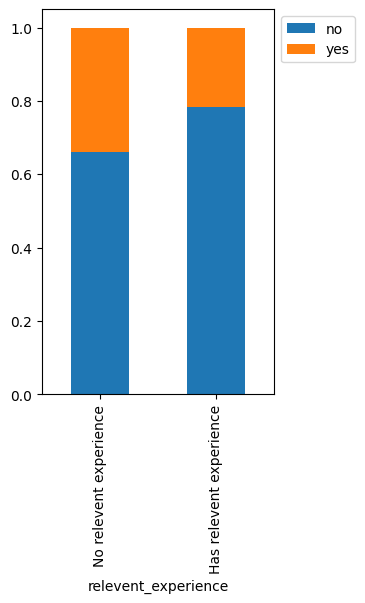

In [129]:
stacked_barplot(data, "relevent_experience", "target")

* 35% of the employees who do not have relevant experience are the ones looking for a job change.
* Such employees might be freshers looking for opportunities.
* 20% of the employees who have relevant experience are also looking for a job change such employees after upskilling might be looking for new roles with the newly acquired skills.

### target vs enrolled_university

target                  no   yes    All
enrolled_university                    
All                  14118  4654  18772
no_enrollment        10896  2921  13817
Full time course      2326  1431   3757
Part time course       896   302   1198
------------------------------------------------------------------------------------------------------------------------


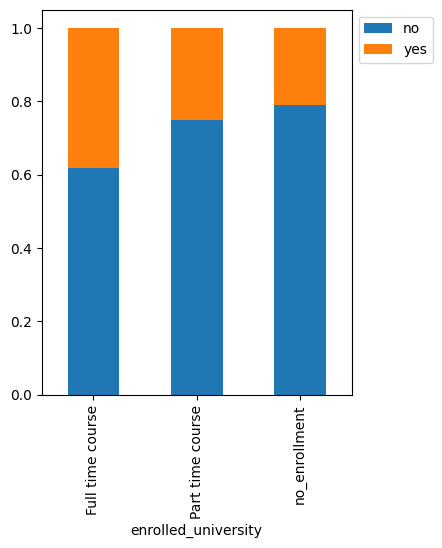

In [130]:
stacked_barplot(data, "enrolled_university", "target")

* There's a high portion of employees looking for a job change across all three categories.
* ~40% of the employees with full-time courses are looking for a job change.
* ~30% of the employees with part-time courses are looking for a job change.

### target vs education_level

target              no   yes    All
education_level                    
All              14025  4673  18698
Graduate          8353  3245  11598
Masters           3426   935   4361
High School       1623   394   2017
Phd                356    58    414
Primary School     267    41    308
------------------------------------------------------------------------------------------------------------------------


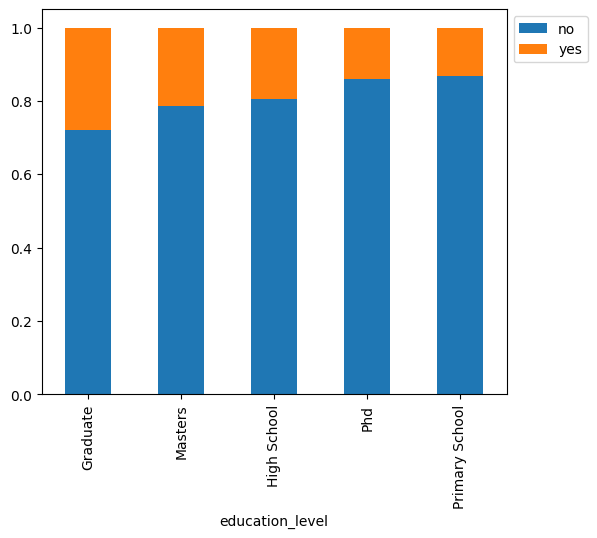

In [131]:
stacked_barplot(data, "education_level", "target")

* There's a high proportion of employees looking for a job change across Graduates, Masters, and High Schooler categories.
* ~30% of the graduate employees are looking for a job change.
* 20% of the employees with a master's degree are looking for a job change.

### target vs major_discipline

target               no   yes    All
major_discipline                    
All               12117  4228  16345
STEM              10701  3791  14492
Humanities          528   141    669
Other               279   102    381
Business Degree     241    86    327
No Major            168    55    223
Arts                200    53    253
------------------------------------------------------------------------------------------------------------------------


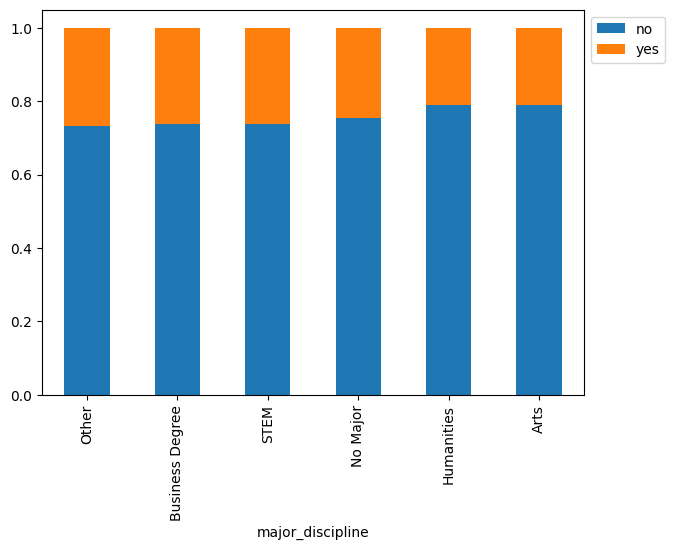

In [132]:
stacked_barplot(data, "major_discipline", "target")

* There's a high proportion of employees looking for a job change across all categories.

### target vs experience

target         no   yes    All
experience                    
All         14339  4754  19093
>20          2783   503   3286
3             876   478   1354
4             946   457   1403
5            1018   412   1430
2             753   374   1127
6             873   343   1216
7             725   303   1028
<1            285   237    522
1             316   233    549
9             767   213    980
10            778   207    985
8             607   195    802
11            513   151    664
15            572   114    686
14            479   107    586
12            402    92    494
13            322    77    399
16            436    72    508
17            285    57    342
19            251    53    304
18            237    43    280
20            115    33    148
------------------------------------------------------------------------------------------------------------------------


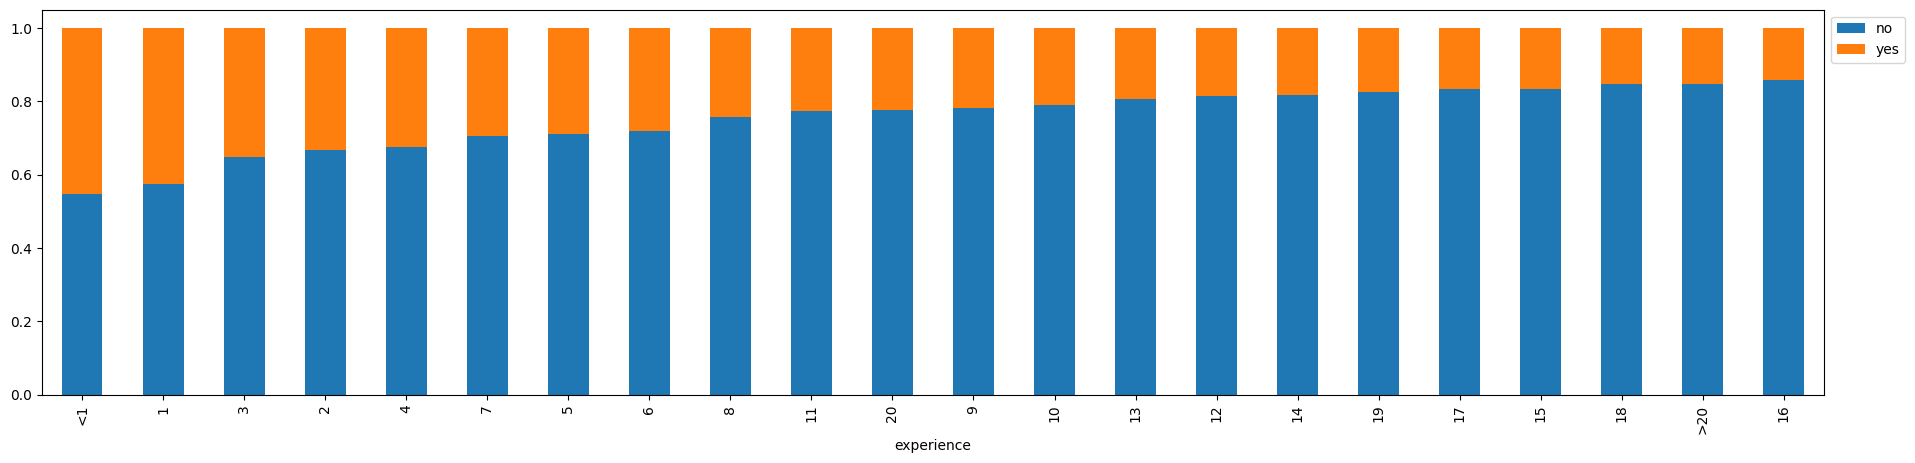

In [133]:
stacked_barplot(data, "experience", "target")

* There's a high proportion of employees looking for a job change having less than 10 years of experience.
* <1 year will the freshers who after training would want to do a job in a relevant field.

### target vs company_size

target           no   yes    All
company_size                    
All           10853  2367  13220
50-99          2538   545   3083
100-500        2156   415   2571
10000+         1634   385   2019
Oct-49         1127   344   1471
<10            1084   224   1308
1000-4999      1128   200   1328
500-999         725   152    877
5000-9999       461   102    563
------------------------------------------------------------------------------------------------------------------------


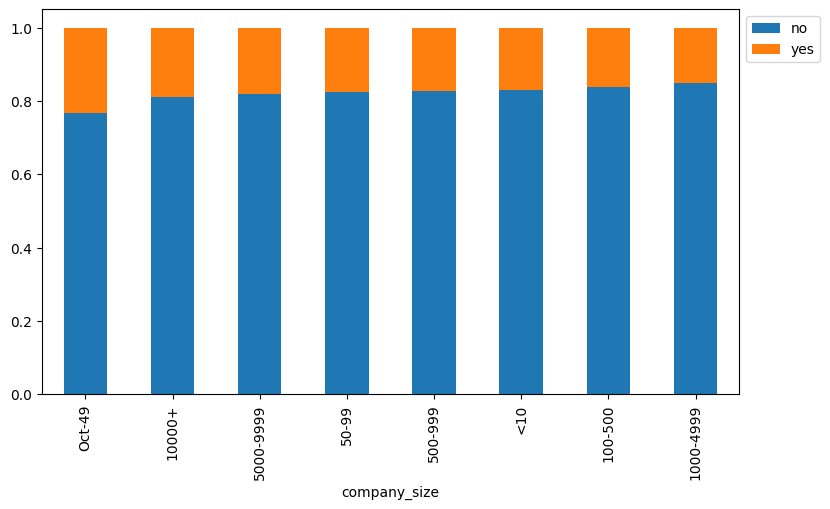

In [134]:
stacked_barplot(data, "company_size", "target")

* ~20% of the employees who have been in companies of different sizes are looking for a job change.

### target vs company_type

target                  no   yes    All
company_type                           
All                  10625  2393  13018
Pvt Ltd               8042  1775   9817
Public Sector          745   210    955
Early Stage Startup    461   142    603
Funded Startup         861   140   1001
NGO                    424    97    521
Other                   92    29    121
------------------------------------------------------------------------------------------------------------------------


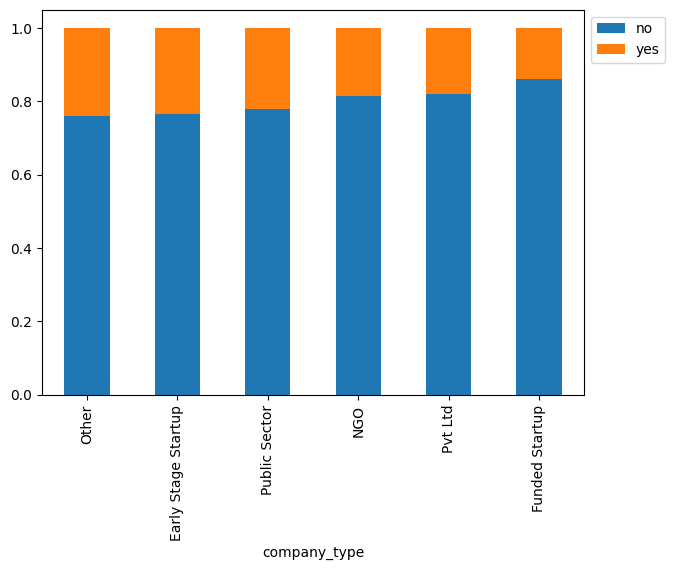

In [135]:
stacked_barplot(data, "company_type", "target")

* employees from funded startups are the ones with less interest a possible reason being their startup just got funded, and they are looking for growth there and just want to upskill by undergoing the training.
* Across all types of companies/sectors ~20% of the employees are looking for a job change.

### target vs last_new_job

target           no   yes    All
last_new_job                    
All           14112  4623  18735
1              5915  2125   8040
never          1713   739   2452
2              2200   700   2900
>4             2690   600   3290
3               793   231   1024
4               801   228   1029
------------------------------------------------------------------------------------------------------------------------


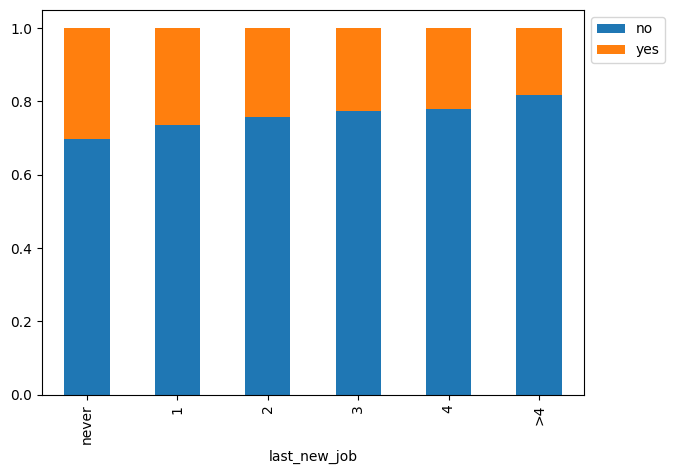

In [136]:
stacked_barplot(data, "last_new_job", "target")

* Our earlier thought of 'never' representing freshers or those who are not working right now seems true as they are the ones most interested in a job change(looking for a start).

In [137]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### target vs training_hours

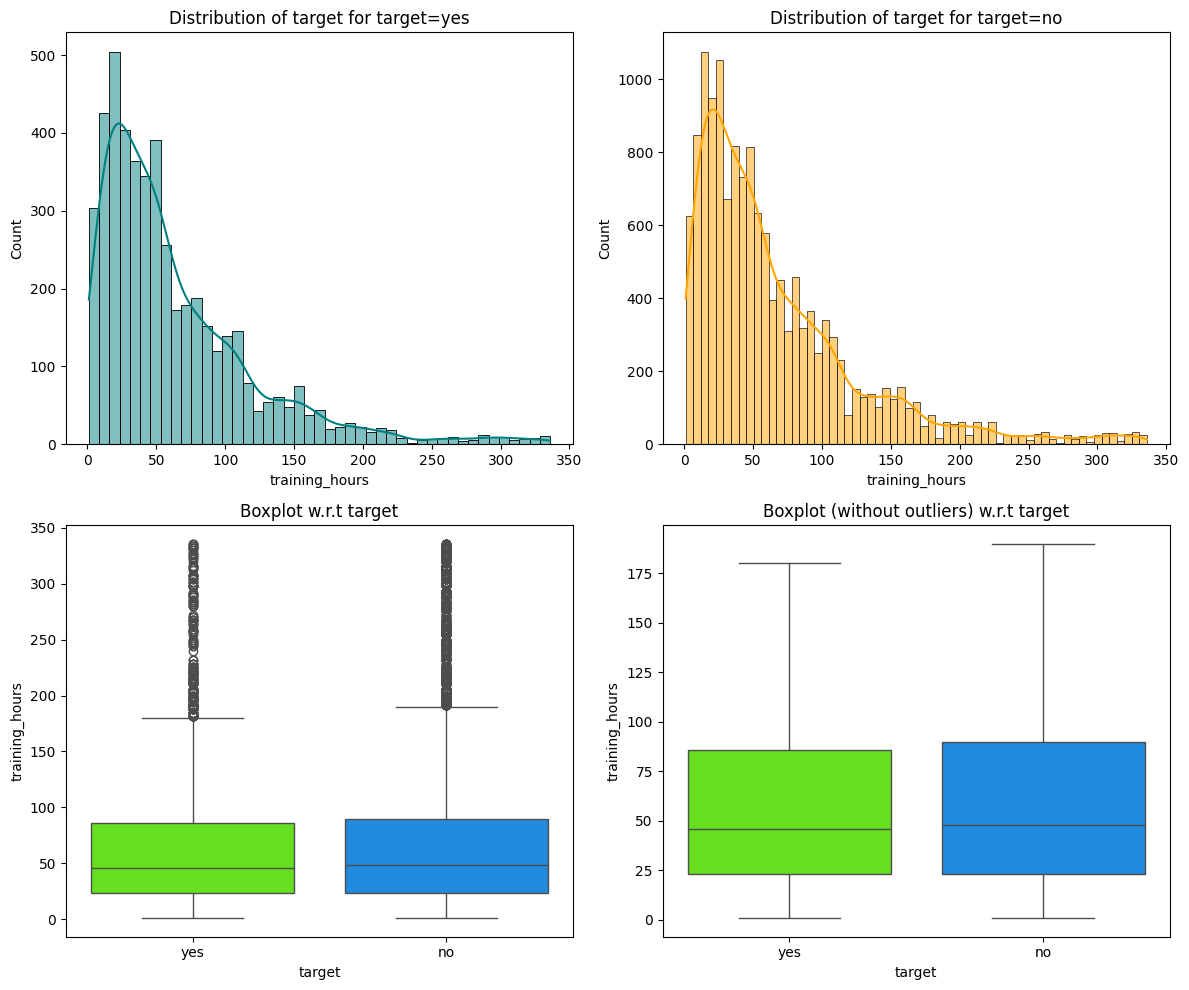

In [138]:
distribution_plot_wrt_target(data, "training_hours", "target")

* Training hours don't seem to have any impact on the target variable.

### target vs city_development_index

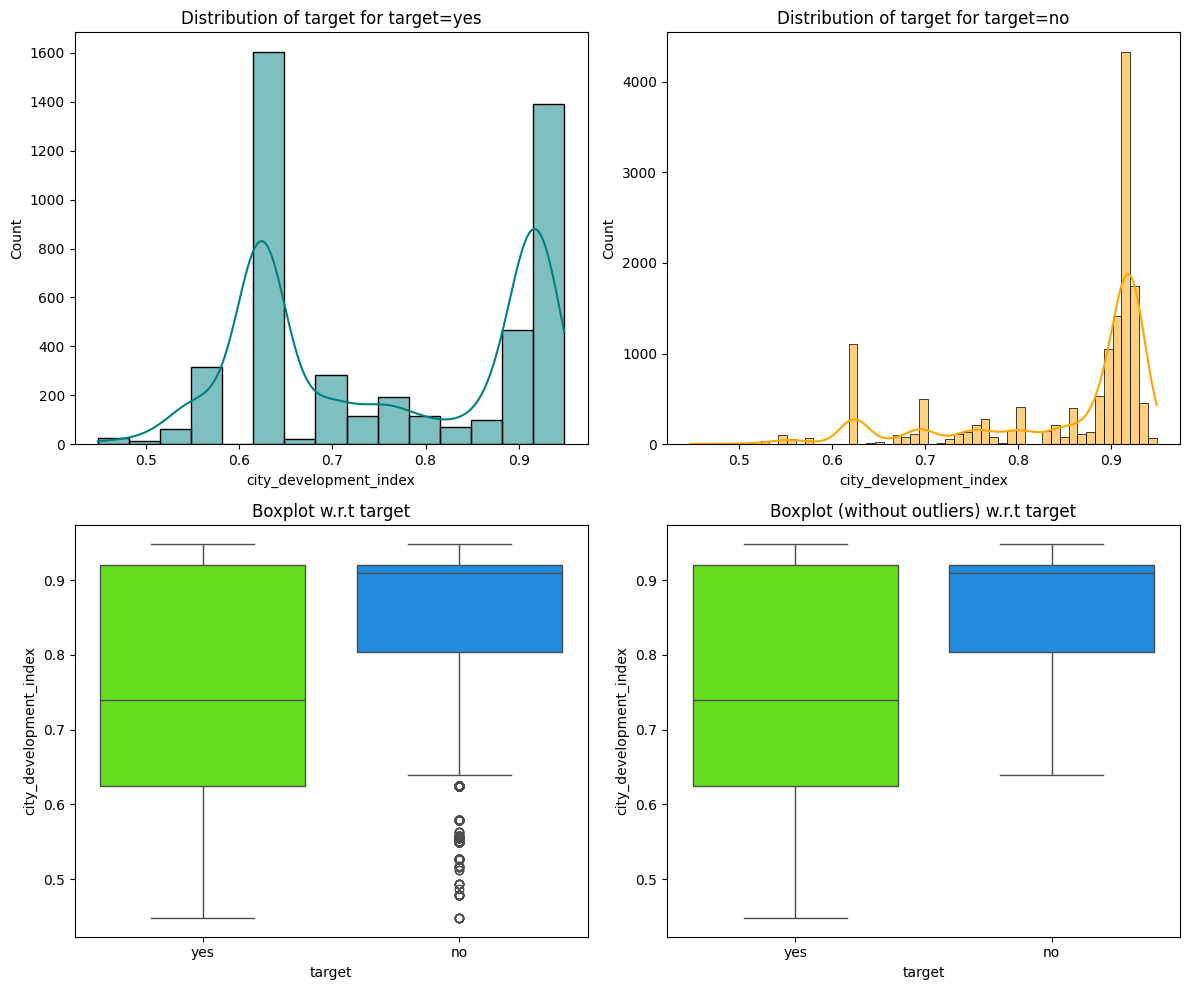

In [139]:
distribution_plot_wrt_target(data, "city_development_index", "target")

* There's a stark difference between the employees looking for a job and an employees not looking for a job.
* employees from a city with a higher development index would be less likely to look for a change in a job as compared to the employees coming from a city with a lower development index.
* Employees coming from cities with a low development index might be looking for better opportunities in metropolitan cities by upskilling themselves after undergoing the training.

### To jump back to the EDA summary section, click <a href = #link2>here</a>.

___